# Predicting Whether the Share Market will Move Up or Down using a Naïve Bayes Classifier

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm

In [2]:
from ISLP import load_data
from ISLP.models import (
    ModelSpec as MS,
    summarize
)
from ISLP import confusion_table
from ISLP.models import contrast

In [11]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

In [4]:
## Set global parameters for plots
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14

## Load and Preprocess the Share Market Data

In [5]:
Smarket = load_data('Smarket')
Smarket

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.19130,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.29650,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.41120,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.27600,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.20570,0.213,Up
...,...,...,...,...,...,...,...,...,...
1245,2005,0.422,0.252,-0.024,-0.584,-0.285,1.88850,0.043,Up
1246,2005,0.043,0.422,0.252,-0.024,-0.584,1.28581,-0.955,Down
1247,2005,-0.955,0.043,0.422,0.252,-0.024,1.54047,0.130,Up
1248,2005,0.130,-0.955,0.043,0.422,0.252,1.42236,-0.298,Down


The column 'Today' represents the 'percentage return' of the S&P 500 stock index on a particular day.  
Percentage return is a metric that represents (profit made / initial investment) * 100% when trading a share.  
For example, the percentage return on the first day is 0.959%.  

If the percentage return on a particular day is positive, the 'Direction' column states 'Up'.  
Otherwise, the 'Direction' column states 'Down'.  
We need to predict the 'Direction' from this dataset.  

To make the prediction, we will take the percentage returns on the previous five days as inputs (denoted by columns 'Lag1' to 'Lag5').  

The column 'Volume' represents the number of S&P 500 listed shares traded on a particular day, in billions.  
For example, 1.19130 billion shares had been traded on the first day.  
We will not use the 'Volume' information for this prediction.  

The 'Year' column represents the year which a particular day belongs to.  
Overall, the dataset contains the percentage returns of the S&P 500 stock index across 1,250 days, from the beginning of 2001 until  
the end of 2005.

**References**  
Section 4.7.1, ISLP.  
S&P 500 stock index: https://en.wikipedia.org/wiki/S%26P_500 .

<Axes: >

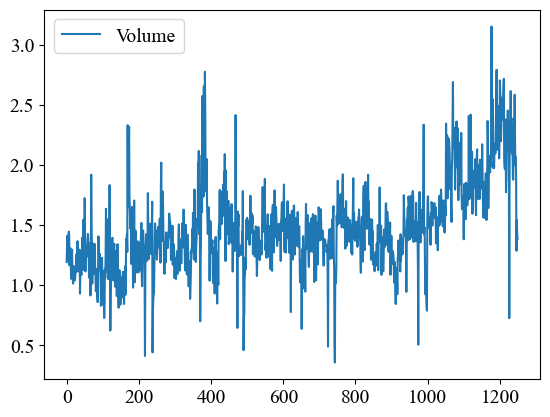

In [6]:
## Plot the volume for fun
Smarket.plot(y='Volume')

In [22]:
Smarket.shape

(1250, 9)

In [46]:
## Use the days before 2005 as the training samples 
train = (Smarket.Year < 2005)
Smarket_train = Smarket.loc[train]
Smarket_train.shape

(998, 9)

In [47]:
## Use the days in 2005 as the test samples
Smarket_test = Smarket.loc[~train]
Smarket_test.shape

(252, 9)

In [61]:
## For the training samples, select only the columns that will be used as predictors
X_train = Smarket_train[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5']]
print(X_train)

      Lag1   Lag2   Lag3   Lag4   Lag5
0    0.381 -0.192 -2.624 -1.055  5.010
1    0.959  0.381 -0.192 -2.624 -1.055
2    1.032  0.959  0.381 -0.192 -2.624
3   -0.623  1.032  0.959  0.381 -0.192
4    0.614 -0.623  1.032  0.959  0.381
..     ...    ...    ...    ...    ...
993  0.046  0.342  0.904  0.038 -0.749
994 -0.431  0.046  0.342  0.904  0.038
995  0.715 -0.431  0.046  0.342  0.904
996 -0.007  0.715 -0.431  0.046  0.342
997  0.008 -0.007  0.715 -0.431  0.046

[998 rows x 5 columns]


In [59]:
## Select the class labels for the training samples
L_train = Smarket_train['Direction']
print(L_train)

0        Up
1        Up
2      Down
3        Up
4        Up
       ... 
993    Down
994      Up
995    Down
996      Up
997    Down
Name: Direction, Length: 998, dtype: category
Categories (2, object): ['Down', 'Up']


In [58]:
## For the test samples, select only the columns that will be used as predictors
X_test = Smarket_test[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5']]
print(X_test)

       Lag1   Lag2   Lag3   Lag4   Lag5
998  -0.134  0.008 -0.007  0.715 -0.431
999  -0.812 -0.134  0.008 -0.007  0.715
1000 -1.167 -0.812 -0.134  0.008 -0.007
1001 -0.363 -1.167 -0.812 -0.134  0.008
1002  0.351 -0.363 -1.167 -0.812 -0.134
...     ...    ...    ...    ...    ...
1245  0.422  0.252 -0.024 -0.584 -0.285
1246  0.043  0.422  0.252 -0.024 -0.584
1247 -0.955  0.043  0.422  0.252 -0.024
1248  0.130 -0.955  0.043  0.422  0.252
1249 -0.298  0.130 -0.955  0.043  0.422

[252 rows x 5 columns]


In [60]:
## Select the class labels for the test samples
L_test = Smarket_test['Direction']
print(L_test)

998     Down
999     Down
1000    Down
1001      Up
1002    Down
        ... 
1245      Up
1246    Down
1247      Up
1248    Down
1249    Down
Name: Direction, Length: 252, dtype: category
Categories (2, object): ['Down', 'Up']


## Train a Gaussian Naive Bayes Classifier

In [62]:
NB = GaussianNB()
NB.fit(X_train , L_train)

,priors,None
,var_smoothing,1e-09


## Test the Gaussian Naive Bayes Classifier

In [63]:
nb_labels = NB.predict(X_test)

In [67]:
## Print the confusion matrix
ct = confusion_table(nb_labels , L_test)
ct

Truth,Down,Up
Predicted,,
Down,36,31
Up,75,110


In [77]:
print(f'No. of test samples = {len(L_test)}')

cpred = np.sum(nb_labels == L_test)
print(f'No. of test samples whose directions have been correctly predicted = {cpred}')

print(f'The prediction accuracy is: {(cpred / len(L_test)) * 100}%')

No. of test samples = 252
No. of test samples whose directions have been correctly predicted = 146
The prediction accuracy is: 57.936507936507944%


## References
Section 4.7.1 and 4.7.5, ISLP.  

Theory behind the naive Bayes classifier: Sections 'Probabilistic model' and 'Examples' of  https://en.wikipedia.org/wiki/Naive_Bayes_classifier .  

The model underlying a Naive Bayes classifier is a simple Bayesian network. Please find the relevant theory behind Bayesian networks in Sections 'Graphical model' and 'Example' of https://en.wikipedia.org/wiki/Bayesian_network .